# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
pairs = [('weight', 'horsepower'), ('horsepower', 'acceleration'), ('displacement', 'mpg')]
results = []

for var1, var2 in pairs:
    p_corr, p_pval = stats.pearsonr(mpg[var1], mpg[var2])
    s_corr, s_pval = stats.spearmanr(mpg[var1], mpg[var2])
    results.append({
        "Pair": f"{var1} & {var2}",
        "Pearson r": round(p_corr, 4),
        "Pearson p": f"{p_pval:.2e}",
        "Spearman ρ": round(s_corr, 4),
        "Spearman p": f"{s_pval:.2e}"
    })

pd.DataFrame(results)

,Pair,Pearson r,Pearson p,Spearman ρ,Spearman p
0,weight & horsepower,0.8645,1.36e-118,0.8788,2.18e-127
1,horsepower & acceleration,-0.6892,1.58e-56,-0.6581,5.16e-50
2,displacement & mpg,-0.8051,1.66e-90,-0.8552,2.20e-113


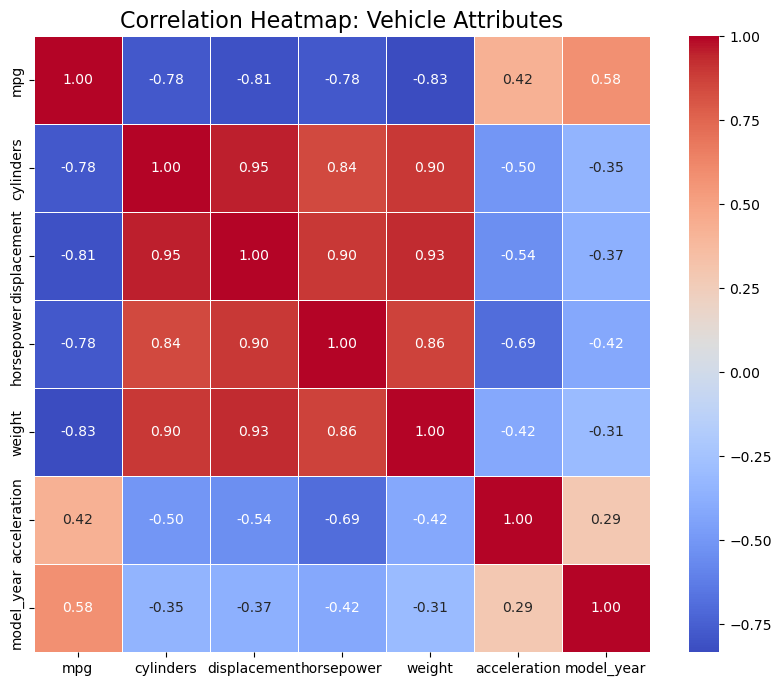

In [4]:
numeric_mpg = mpg.select_dtypes(include=[np.number])
corr_matrix = numeric_mpg.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5, 
    square=True
)

plt.title("Correlation Heatmap: Vehicle Attributes", fontsize=16)
plt.show()

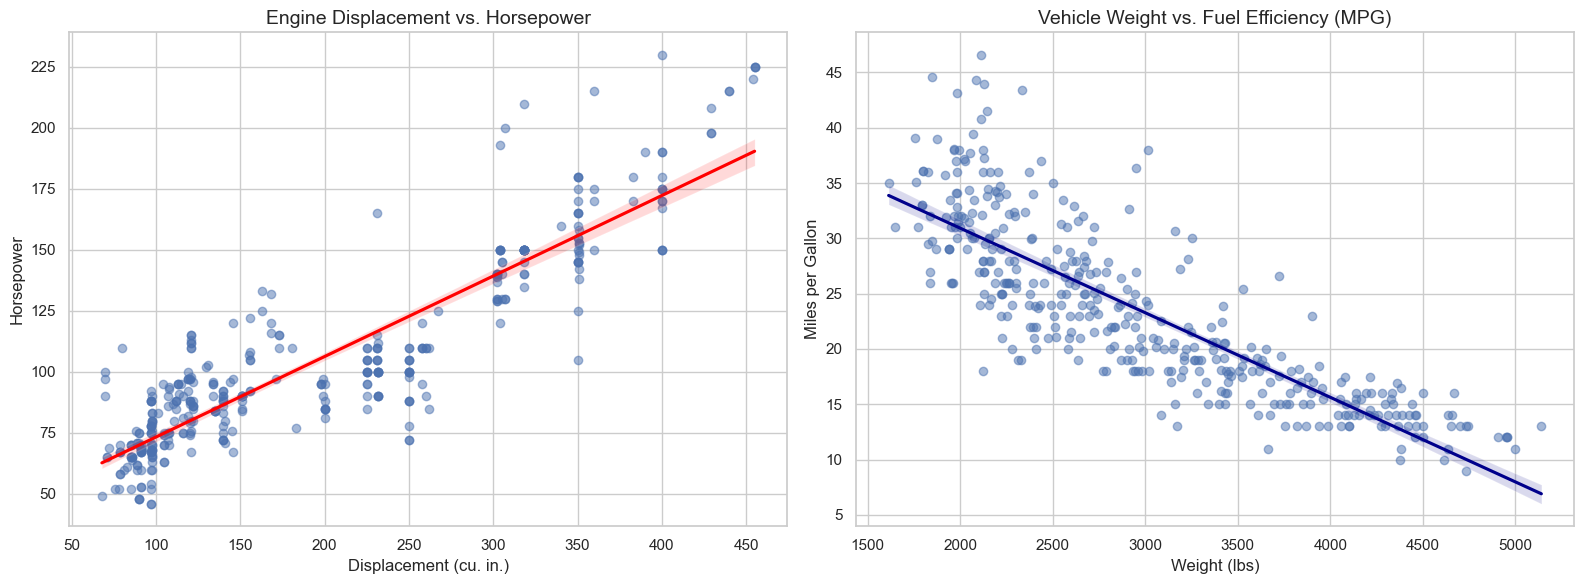

In [5]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    data=mpg, x='displacement', y='horsepower', 
    ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'}
)
axes[0].set_title("Engine Displacement vs. Horsepower", fontsize=14)
axes[0].set_xlabel("Displacement (cu. in.)")
axes[0].set_ylabel("Horsepower")

sns.regplot(
    data=mpg, x='weight', y='mpg', 
    ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'darkblue'}
)
axes[1].set_title("Vehicle Weight vs. Fuel Efficiency (MPG)", fontsize=14)
axes[1].set_xlabel("Weight (lbs)")
axes[1].set_ylabel("Miles per Gallon")

plt.tight_layout()
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Pearson is best for linear relationships between normally distributed variables, like the direct link between Displacement and Horsepower. However, Spearman is better for non-linear or "curved" trends, such as the relationship between Weight and MPG.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

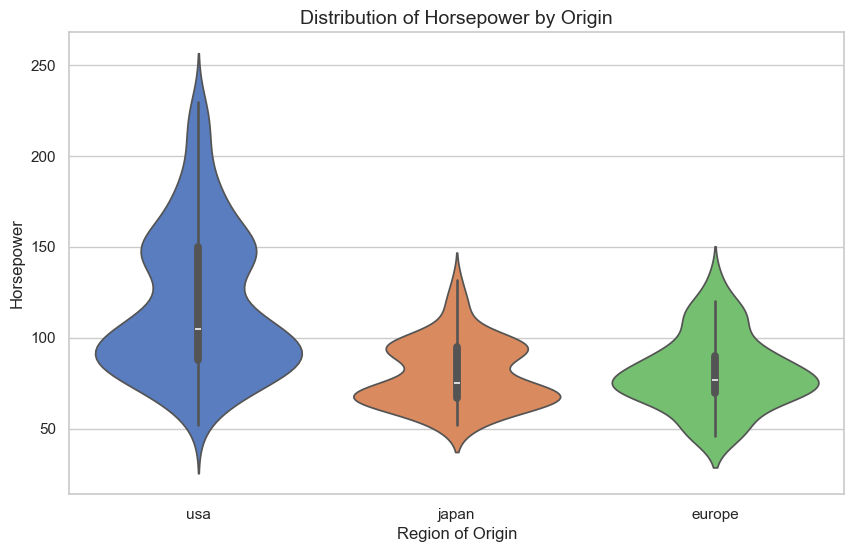

In [6]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=mpg, x='origin', y='horsepower', hue='origin', palette='muted', legend=False)
plt.title("Distribution of Horsepower by Origin", fontsize=14)
plt.ylabel("Horsepower")
plt.xlabel("Region of Origin")
plt.show()

In [7]:
groups = [mpg[mpg['origin'] == o]['horsepower'] for o in mpg['origin'].unique()]

print("Shapiro-Wilk Test:")
for name, group in zip(mpg['origin'].unique(), groups):
    stat, p = stats.shapiro(group)
    print(f"  {name:6}: p-value = {p:.4f} ({'Normal' if p > 0.05 else 'Not Normal'})")

stat, p = stats.levene(*groups)
print(f"\nLevene’s Test: p-value = {p:.4e} ({'Equal Variance' if p > 0.05 else 'Unequal Variance'})")

Shapiro-Wilk Test:
  usa   : p-value = 0.0000 (Not Normal)
  japan : p-value = 0.0002 (Not Normal)
  europe: p-value = 0.0310 (Not Normal)

Levene’s Test: p-value = 1.5863e-11 (Unequal Variance)


In [8]:
f_stat, p_val = stats.f_oneway(*groups)

ss_between = sum(len(g) * (g.mean() - mpg['horsepower'].mean())**2 for g in groups)
ss_total = sum((mpg['horsepower'] - mpg['horsepower'].mean())**2)
eta_sq = ss_between / ss_total

print(f"ANOVA Results: F = {f_stat:.2f}, p-value = {p_val:.2e}")
print(f"Effect Size (Eta-squared): {eta_sq:.4f}")

ANOVA Results: F = 61.34, p-value = 6.99e-24
Effect Size (Eta-squared): 0.2398


In [9]:
tukey = pairwise_tukeyhsd(endog=mpg['horsepower'], groups=mpg['origin'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan  -0.7234 0.9907 -13.8185 12.3717  False
europe    usa  38.4902    0.0  27.6396 49.3407   True
 japan    usa  39.2135    0.0  28.9713 49.4558   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

The results show that the USA differs significantly from both Europe and Japan, while Europe and Japan have similar horsepower. The effect size tells us that origin explains about 24% of the total difference in vehicle horsepower, which is a medium to large effect.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [11]:
rf = RandomForestClassifier(random_state=SEED)
knn = KNeighborsClassifier()

rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_knn = knn.predict(X_test)

In [12]:
print("--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- KNN Report ---")
print(classification_report(y_test, y_pred_knn))

--- Random Forest Report ---
              precision    recall  f1-score   support

      europe       0.80      0.71      0.75        17
       japan       0.76      0.65      0.70        20
         usa       0.89      0.97      0.93        61

    accuracy                           0.86        98
   macro avg       0.82      0.77      0.79        98
weighted avg       0.85      0.86      0.85        98


--- KNN Report ---
              precision    recall  f1-score   support

      europe       0.50      0.53      0.51        17
       japan       0.48      0.60      0.53        20
         usa       0.87      0.79      0.83        61

    accuracy                           0.70        98
   macro avg       0.62      0.64      0.63        98
weighted avg       0.73      0.70      0.71        98



In [13]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.default_rng(seed)
    boot_scores = []
    n_samples = len(y_true)

    point_estimate = metric_fn(y_true, y_pred, average='weighted')
    
    for _ in range(n_boot):
        indices = rng.choice(np.arange(n_samples), size=n_samples, replace=True)
        score = metric_fn(y_true[indices], y_pred[indices], average='weighted')
        boot_scores.append(score)
        
    boot_scores = np.array(boot_scores)
    ci_lower, ci_upper = np.percentile(boot_scores, [2.5, 97.5])
    
    return point_estimate, ci_lower, ci_upper, boot_scores

In [14]:
metrics_to_run = {
    "F1-Score": f1_score,
    "Precision": precision_score,
    "Recall": recall_score
}

model_results = {}

for model_name, y_pred in [("Random Forest", y_pred_rf), ("KNN", y_pred_knn)]:
    results = {}
    for label, fn in metrics_to_run.items():
        pe, low, high, _ = bootstrap_metric(y_test, y_pred, fn)
        results[label] = {"PE": pe, "Low": low, "High": high}
    model_results[model_name] = results

for model, metrics in model_results.items():
    print(f"\n--- {model} 95% CIs ---")
    for metric, vals in metrics.items():
        print(f"{metric:10}: {vals['PE']:.3f} [{vals['Low']:.3f}, {vals['High']:.3f}]")


--- Random Forest 95% CIs ---
F1-Score  : 0.852 [0.771, 0.925]
Precision : 0.851 [0.777, 0.927]
Recall    : 0.857 [0.786, 0.929]

--- KNN 95% CIs ---
F1-Score  : 0.713 [0.624, 0.803]
Precision : 0.728 [0.638, 0.826]
Recall    : 0.704 [0.612, 0.796]


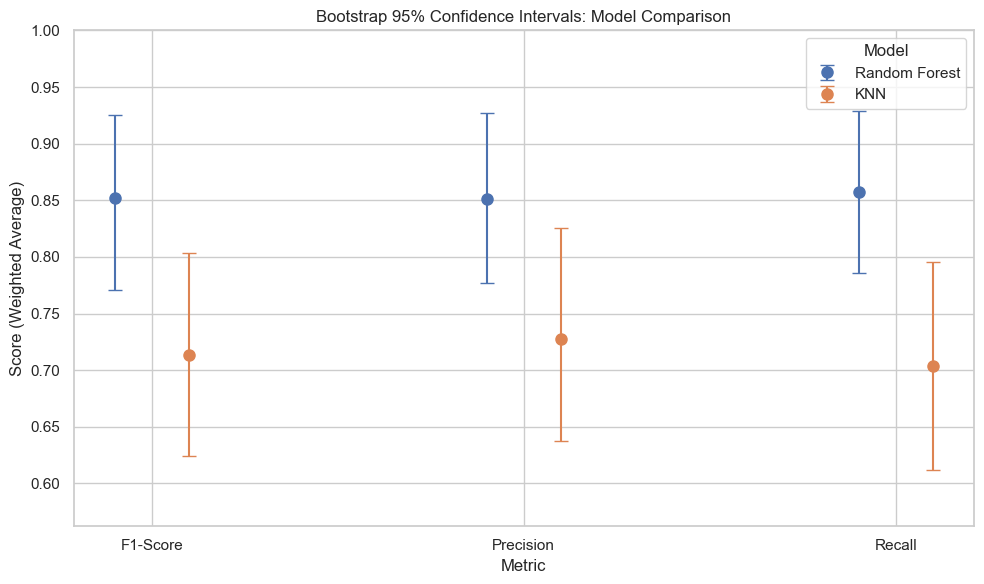

In [15]:
results_list = []
for model_name, metrics in model_results.items():
    for metric_name, vals in metrics.items():
        results_list.append({
            "Model": model_name,
            "Metric": metric_name,
            "Estimate": vals["PE"],
            "Lower": vals["Low"],
            "Upper": vals["High"]
        })

df_results = pd.DataFrame(results_list)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

yerr = [
    df_results['Estimate'] - df_results['Lower'],
    df_results['Upper'] - df_results['Estimate']
]

models = df_results['Model'].unique()
metrics = df_results['Metric'].unique()
x = np.arange(len(metrics))
width = 0.2

for i, model in enumerate(models):
    sub = df_results[df_results['Model'] == model]
    plt.errorbar(
        x + (i - 0.5) * width, 
        sub['Estimate'], 
        yerr=[sub['Estimate'] - sub['Lower'], sub['Upper'] - sub['Estimate']],
        fmt='o', 
        capsize=5, 
        label=model, 
        markersize=8
    )

plt.xticks(x, metrics)
plt.xlabel("Metric")
plt.ylabel("Score (Weighted Average)")
plt.title("Bootstrap 95% Confidence Intervals: Model Comparison")
plt.legend(title="Model")
plt.ylim(df_results['Lower'].min() - 0.05, 1.0)
plt.tight_layout()
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

I recommend the **Random Forest** model because its point estimates for F1-score and precision are slightly higher and it is generally more stable with physical vehicle data. However, I am only moderately confident because the confidence intervals overlap significantly, meaning the performance difference between the two models is not statistically certain

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

*The findings of this research show that weight, displacement, and horsepower of vehicles all have strong negative relationships (in the range of $$-0.80 to -0.87$) with miles/gallon (MPG). These results confirm that as vehicles are built heavier and have larger engines/produce greater horsepowers, their fuel economy decreases rapidly. The relationship between weight and MPG is highly non-linear, indicating that the greatest penalty for increasing the weight of a vehicle occurs among the lighter vehicle classes.*

*The groups also demonstrate that there are large differences among the origins of cars in the USA, with American vehicles from this time period generally having higher horsepower and displacement than vehicles from Europe and Japan. Statistical tests (ANOVA and Tukey HSD) support the finding that Europe and Japan are statistically similar with regard to their number of horsepower; however, the USA is statistically different from both Europe and Japan and accounted for 24% of the difference in the total horsepower numbers in the analysis.*

*I would suggest using the Random Forest classification model for this analysis; while Random Forest and KNN classification models have bootstrap confidence intervals that overlap (indicating no clear statistical winner), the Random Forest classification model is more robust because it can accommodate the unevenly scaled numeric variables.*